#  Linear Regression 


---

## What We'll Cover Today

| # | Topic | Key Idea |
|---|-------|----------|
| 1 | Intuition & Setup | What is regression? Why do we need it? |
| 2 | Simple Linear Regression | One input → one output |
| 3 | The Math Behind It | Slope, intercept, cost function |
| 4 | Gradient Descent | How the model *learns* |
| 5 | Multiple Linear Regression | Many inputs → one output |
| 6 | Evaluation Metrics | How good is our model? |
| 7 | Assumptions & Diagnostics | When does LR work? |
| 8 | Regularization (Ridge & Lasso) | Preventing overfitting |

---


##  Environment Setup

Run this cell first to import everything we need.

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ─────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'primary': '#2563EB', 'secondary': '#DC2626', 
          'accent': '#059669', 'highlight': '#D97706'}
np.random.seed(42)

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


---
## 1️What is Linear Regression?

**Definition:** Linear Regression models the relationship between a **dependent variable (y)** and one or more **independent variables (X)** by fitting a straight line (or hyperplane).

### Real-world examples
- **House price** vs. area in sq ft
- **Ice cream sales** vs. temperature
- **Exam score** vs. hours studied
- **Salary** vs. years of experience

### The Core Equation

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n$$

| Symbol | Name | Meaning |
|--------|------|---------|
| $\hat{y}$ | Predicted value | What the model outputs |
| $\theta_0$ | Intercept (bias) | Value of y when all x = 0 |
| $\theta_i$ | Coefficient (weight) | Effect of feature $x_i$ on y |



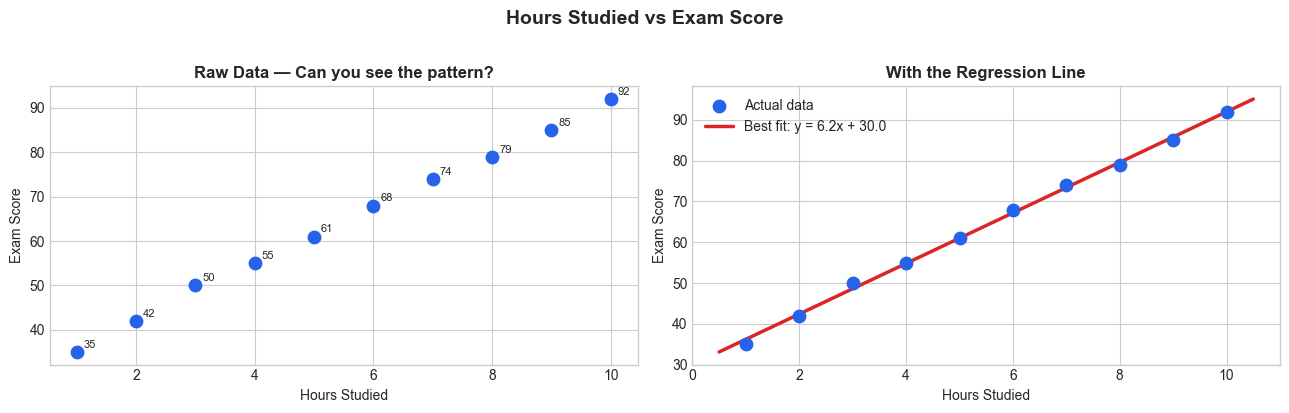

 Equation: Score = 6.20 × Hours + 30.00
 Interpretation: Each extra hour of study adds ~6.2 points!


In [2]:
# ── DEMO: The simplest possible regression ──────────────────────────────────
# Hours studied vs Exam Score

hours  = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
scores = np.array([35, 42, 50, 55, 61, 68, 74, 79, 85, 92])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Just the data
axes[0].scatter(hours, scores, color=COLORS['primary'], s=80, zorder=3)
axes[0].set_title('Raw Data — Can you see the pattern?', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hours Studied'); axes[0].set_ylabel('Exam Score')
for h, s in zip(hours, scores):
    axes[0].annotate(f'{s}', (h, s), textcoords='offset points', xytext=(5, 3), fontsize=8)

# Right: Data + best fit line
m, b = np.polyfit(hours, scores, 1)   # simple least-squares fit
x_line = np.linspace(0.5, 10.5, 100)
axes[1].scatter(hours, scores, color=COLORS['primary'], s=80, zorder=3, label='Actual data')
axes[1].plot(x_line, m * x_line + b, color=COLORS['secondary'], lw=2.5, label=f'Best fit: y = {m:.1f}x + {b:.1f}')
axes[1].set_title('With the Regression Line', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hours Studied'); axes[1].set_ylabel('Exam Score')
axes[1].legend()

plt.suptitle('Hours Studied vs Exam Score', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f" Equation: Score = {m:.2f} × Hours + {b:.2f}")
print(f" Interpretation: Each extra hour of study adds ~{m:.1f} points!")

---
## 2️ The Math — Residuals & Cost Function

### Residuals (Errors)
The **residual** for a data point is how far the prediction is from the actual value:

$$e_i = y_i - \hat{y}_i$$

### Mean Squared Error (MSE) — Our Cost Function

We want to find the line that **minimizes the total error**:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2 = \frac{1}{2m} \sum_{i=1}^{m} (\theta_0 + \theta_1 x_i - y_i)^2$$

Why **squared** error?
-  Penalizes large errors more
-  Always positive (no cancellation)
-  Differentiable (needed for optimization)


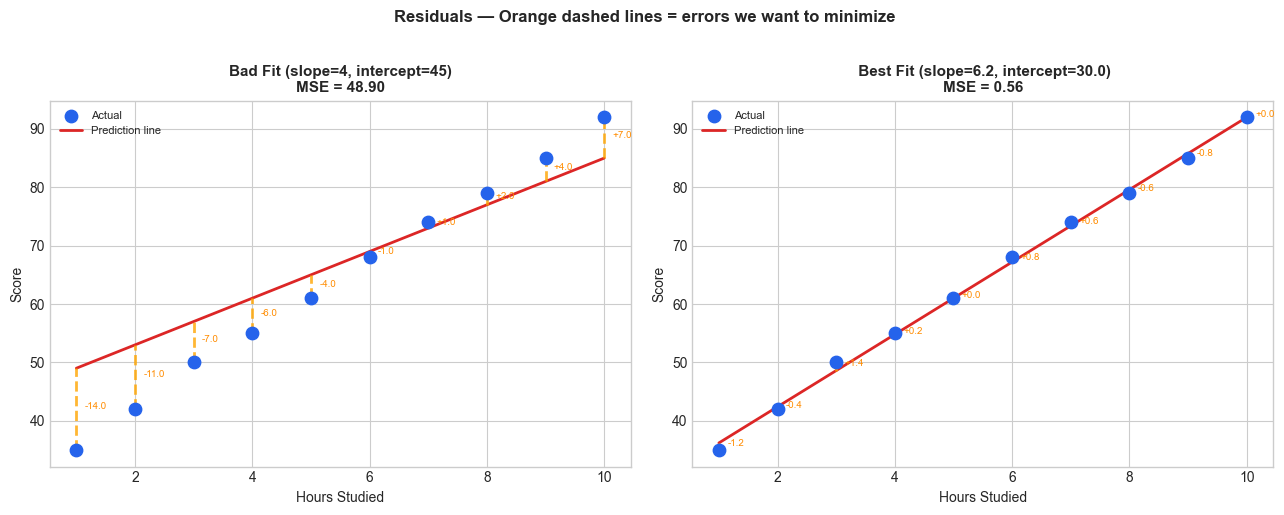

In [3]:
# ── VISUALIZING RESIDUALS ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def plot_residuals(ax, slope, intercept, title):
    y_pred = slope * hours + intercept
    residuals = scores - y_pred
    mse = np.mean(residuals**2)
    
    ax.scatter(hours, scores, color=COLORS['primary'], s=80, zorder=3, label='Actual')
    ax.plot(hours, y_pred, color=COLORS['secondary'], lw=2, label='Prediction line')
    
    for i, (h, s, p) in enumerate(zip(hours, scores, y_pred)):
        ax.vlines(h, min(s, p), max(s, p), colors='orange', lw=2, linestyle='--', alpha=0.8)
        ax.annotate(f'{residuals[i]:+.1f}', (h, (s + p)/2),
                    textcoords='offset points', xytext=(6, 0), fontsize=7, color='darkorange')
    
    ax.set_title(f'{title}\nMSE = {mse:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Hours Studied'); ax.set_ylabel('Score')
    ax.legend(fontsize=8)

# Bad fit
plot_residuals(axes[0], slope=4, intercept=45, title='Bad Fit (slope=4, intercept=45)')

# Best fit
plot_residuals(axes[1], slope=m, intercept=b, title=f' Best Fit (slope={m:.1f}, intercept={b:.1f})')

plt.suptitle('Residuals — Orange dashed lines = errors we want to minimize', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3️ Finding the Best Line — Two Approaches

### Approach A: Normal Equation (Closed-Form Solution)

Minimize MSE analytically by taking the derivative and setting it to zero:

$$\theta = (X^T X)^{-1} X^T y$$

**Pros:** Exact solution, no tuning needed  
**Cons:** Slow for very large datasets (matrix inversion is $O(n^3)$)

### Approach B: Gradient Descent (Iterative)

Update parameters step by step, moving in the direction of steepest descent:

$$\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$

Where $\alpha$ is the **learning rate** — how big a step we take each iteration.

**Pros:** Scales to millions of data points  
**Cons:** Needs tuning (learning rate, iterations)



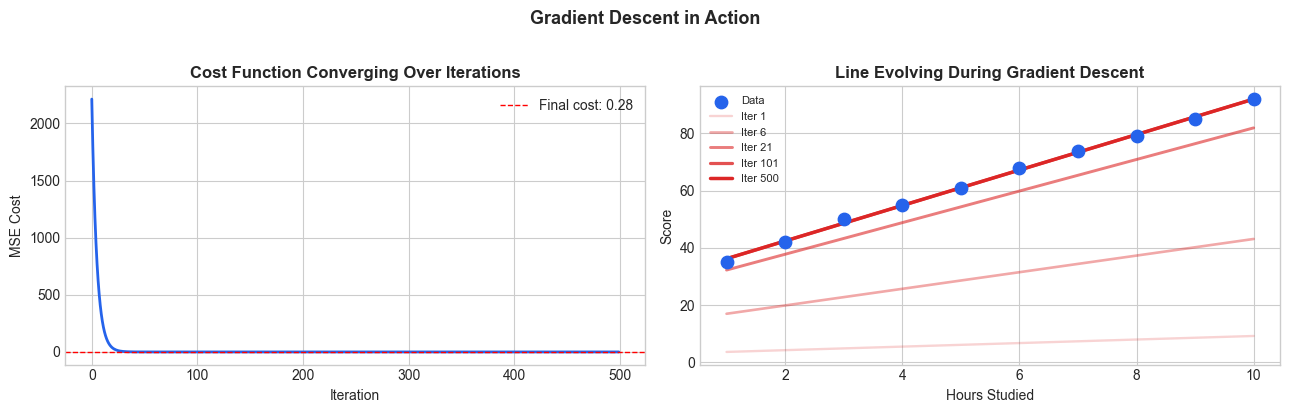

Final parameters: intercept=64.10, slope=17.81
Cost reduced from 2213.25 → 0.28


In [4]:
# ── GRADIENT DESCENT FROM SCRATCH ───────────────────────────────────────────

def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    m = len(y)
    theta = np.zeros(2)      # [intercept, slope]
    cost_history = []
    theta_history = []
    
    X_b = np.c_[np.ones(m), X]   # Add bias column (x0 = 1)
    
    for i in range(n_iterations):
        predictions = X_b @ theta
        errors = predictions - y
        
        # Compute gradients
        gradients = (1/m) * X_b.T @ errors
        
        # Update parameters
        theta -= learning_rate * gradients
        
        # Track cost
        cost = (1/(2*m)) * np.sum(errors**2)
        cost_history.append(cost)
        theta_history.append(theta.copy())
    
    return theta, cost_history, theta_history

# Run it!
X_norm = (hours - hours.mean()) / hours.std()   # normalize for stability
theta_final, cost_hist, theta_hist = gradient_descent(X_norm, scores, 
                                                       learning_rate=0.1, 
                                                       n_iterations=500)

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cost curve
axes[0].plot(cost_hist, color=COLORS['primary'], lw=2)
axes[0].set_title('Cost Function Converging Over Iterations', fontweight='bold')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE Cost')
axes[0].axhline(y=cost_hist[-1], color='red', lw=1, linestyle='--', label=f'Final cost: {cost_hist[-1]:.2f}')
axes[0].legend()

# Show a few intermediate lines
axes[1].scatter(hours, scores, color=COLORS['primary'], s=80, zorder=5, label='Data')
checkpoints = [0, 5, 20, 100, 499]
alphas = [0.2, 0.4, 0.6, 0.8, 1.0]
for idx, alpha in zip(checkpoints, alphas):
    t = theta_hist[idx]
    y_pred = t[0] + t[1] * X_norm
    axes[1].plot(hours, y_pred, color=COLORS['secondary'], alpha=alpha, lw=1.5 + alpha,
                label=f'Iter {idx+1}')
axes[1].set_title('Line Evolving During Gradient Descent', fontweight='bold')
axes[1].set_xlabel('Hours Studied'); axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)

plt.suptitle('Gradient Descent in Action', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Final parameters: intercept={theta_final[0]:.2f}, slope={theta_final[1]:.2f}")
print(f"Cost reduced from {cost_hist[0]:.2f} → {cost_hist[-1]:.2f}")

---
## 4️ Effect of Learning Rate

The **learning rate $\alpha$** is one of the most important hyperparameters.

| Learning Rate | Effect |
|---------------|--------|
| Too small | Very slow convergence |
| Just right | Smooth, steady convergence |
| Too large | Oscillates or diverges! |

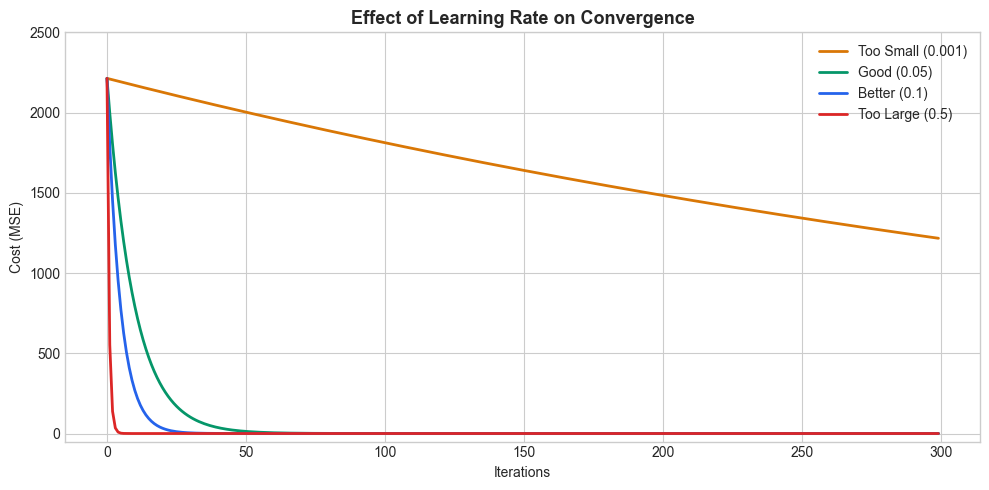

 Key Takeaway:
   • Too small  → takes too long to converge
   • Just right → steady decrease, reaches minimum
   • Too large  → may bounce around or blow up


In [5]:
# ── COMPARING LEARNING RATES ─────────────────────────────────────────────────

learning_rates = [0.001, 0.05, 0.1, 0.5]
labels         = ['Too Small (0.001)', 'Good (0.05)', 'Better (0.1)', 'Too Large (0.5)']
line_colors    = [COLORS['highlight'], COLORS['accent'], COLORS['primary'], COLORS['secondary']]

fig, ax = plt.subplots(figsize=(10, 5))

for lr, label, color in zip(learning_rates, labels, line_colors):
    _, cost_h, _ = gradient_descent(X_norm, scores, learning_rate=lr, n_iterations=300)
    ax.plot(cost_h, label=label, color=color, lw=2)

ax.set_title('Effect of Learning Rate on Convergence', fontsize=13, fontweight='bold')
ax.set_xlabel('Iterations')
ax.set_ylabel('Cost (MSE)')
ax.set_ylim(-50, 2500)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(" Key Takeaway:")
print("   • Too small  → takes too long to converge")
print("   • Just right → steady decrease, reaches minimum")
print("   • Too large  → may bounce around or blow up")

---
## 5️ Using Scikit-Learn for Linear Regression

In practice, we use **scikit-learn** — it handles all the math for us.

The workflow is always:
```
1. Load data
2. Split into train / test
3. Create model
4. Fit (train) model
5. Predict
6. Evaluate
```

Train size: 15  |  Test size: 5

 Model Parameters:
   Intercept (θ₀) = $32,125
   Slope     (θ₁) = $7,764 per year

 Interpretation: Starting salary ≈ $32,125
   Each year of experience adds ≈ $7,764 to salary


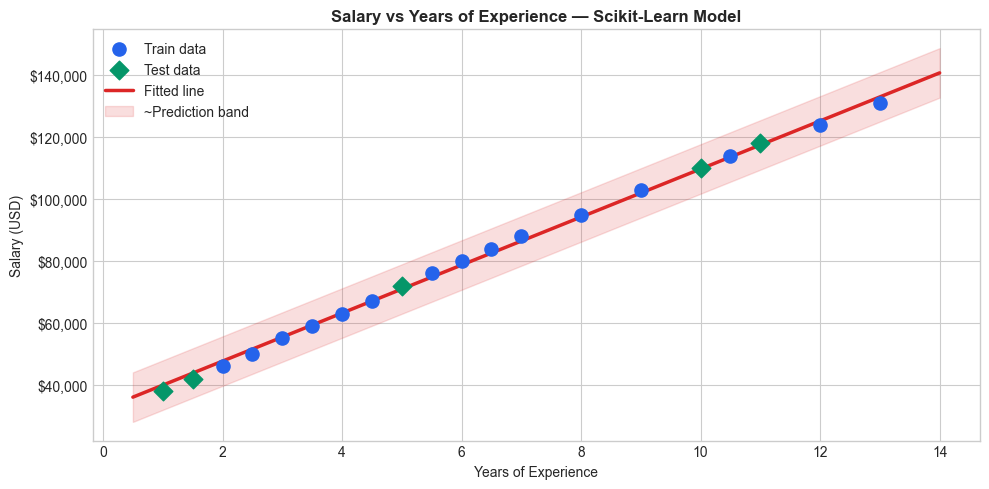

In [6]:
# ── SCIKIT-LEARN PIPELINE ───────────────────────────────────────────────────

# Dataset: Salary vs Years of Experience
years_exp = np.array([1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7,8,9,10,10.5,11,12,13])
salary    = np.array([38,42,46,50,55,59,63,67,72,76,80,84,88,95,103,110,114,118,124,131]) * 1000

X = years_exp.reshape(-1, 1)   # sklearn expects 2D array
y = salary

# Step 1: Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# Step 2: Create & Train model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\n Model Parameters:")
print(f"   Intercept (θ₀) = ${model.intercept_:,.0f}")
print(f"   Slope     (θ₁) = ${model.coef_[0]:,.0f} per year")
print(f"\n Interpretation: Starting salary ≈ ${model.intercept_:,.0f}")
print(f"   Each year of experience adds ≈ ${model.coef_[0]:,.0f} to salary")

# Step 3: Predict
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(X_train, y_train, color=COLORS['primary'], s=90, label='Train data', zorder=3)
ax.scatter(X_test,  y_test,  color=COLORS['accent'],  s=90, marker='D', label='Test data', zorder=3)

x_range = np.linspace(0.5, 14, 100).reshape(-1, 1)
ax.plot(x_range, model.predict(x_range), color=COLORS['secondary'], lw=2.5, label='Fitted line')

# Shade prediction interval roughly
y_line = model.predict(x_range).flatten()
ax.fill_between(x_range.flatten(), y_line - 8000, y_line + 8000, 
                alpha=0.15, color=COLORS['secondary'], label='~Prediction band')

ax.set_title('Salary vs Years of Experience — Scikit-Learn Model', fontsize=12, fontweight='bold')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Salary (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 6️ Model Evaluation Metrics

How do we know if our model is any good?

| Metric | Formula | What it means | Units |
|--------|---------|---------------|-------|
| **MAE** | $\frac{1}{m}\sum|y - \hat{y}|$ | Average absolute error | Same as y |
| **MSE** | $\frac{1}{m}\sum(y - \hat{y})^2$ | Average squared error | y² |
| **RMSE** | $\sqrt{MSE}$ | Root mean squared error | Same as y |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | % of variance explained | 0 to 1 (higher=better) |

### R² Score Intuition
- **R² = 1.0** → Perfect predictions
- **R² = 0.8** → Model explains 80% of variation
- **R² = 0.0** → Model is no better than predicting the mean
- **R² < 0**   → Model is worse than predicting the mean!


  Training Metrics:
   MAE  = $  1,000.76  (avg absolute error)
   MSE  = $1,357,075.06
   RMSE = $  1,164.94  (typical error, same units as y)
   R²   = 0.9980         (99.8% of variance explained)

  Test Metrics:
   MAE  = $  1,083.34  (avg absolute error)
   MSE  = $1,618,297.56
   RMSE = $  1,272.12  (typical error, same units as y)
   R²   = 0.9985         (99.9% of variance explained)


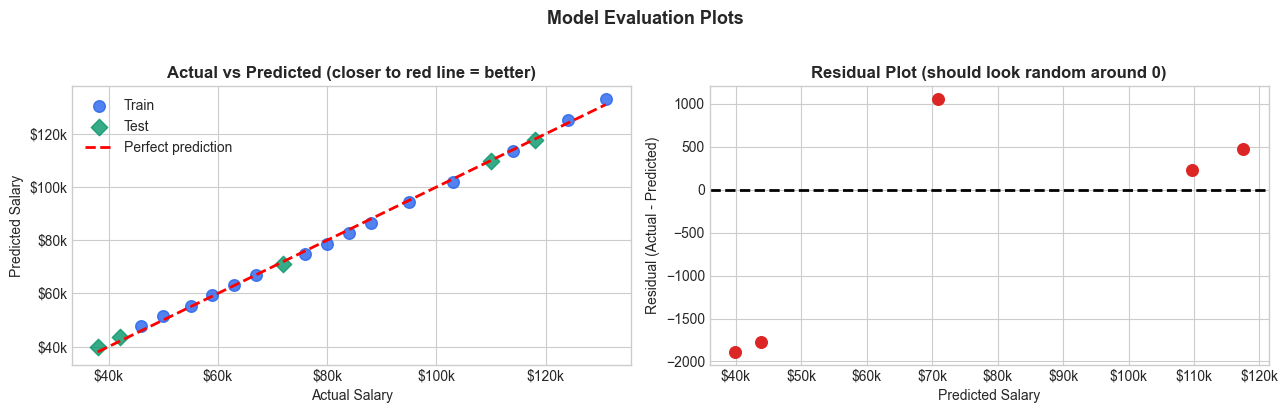

In [7]:
# ── EVALUATION METRICS ───────────────────────────────────────────────────────

def evaluate_model(y_true, y_pred, dataset_name=''):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    
    print(f"\n {dataset_name} Metrics:")
    print(f"   MAE  = ${mae:>10,.2f}  (avg absolute error)")
    print(f"   MSE  = ${mse:>10,.2f}")
    print(f"   RMSE = ${rmse:>10,.2f}  (typical error, same units as y)")
    print(f"   R²   = {r2:.4f}         ({r2*100:.1f}% of variance explained)")
    return mae, rmse, r2

train_metrics = evaluate_model(y_train, y_pred_train, ' Training')
test_metrics  = evaluate_model(y_test,  y_pred_test,  ' Test')

# ── Visual: Actual vs Predicted ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Actual vs Predicted scatter
all_actual = np.concatenate([y_train, y_test])
all_pred   = np.concatenate([y_pred_train, y_pred_test])
axes[0].scatter(y_train, y_pred_train, color=COLORS['primary'], s=70, label='Train', alpha=0.8)
axes[0].scatter(y_test,  y_pred_test,  color=COLORS['accent'],  s=70, label='Test',  marker='D', alpha=0.8)
min_v, max_v = all_actual.min(), all_actual.max()
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Salary'); axes[0].set_ylabel('Predicted Salary')
axes[0].set_title('Actual vs Predicted (closer to red line = better)', fontweight='bold')
axes[0].legend(); axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x/1000:.0f}k'))

# Residual plot
residuals_test = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals_test, color=COLORS['secondary'], s=70)
axes[1].axhline(0, color='black', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted Salary'); axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot (should look random around 0)', fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x/1000:.0f}k'))

plt.suptitle('Model Evaluation Plots', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7️ Multiple Linear Regression

Real-world problems have **multiple features**. For example, to predict house price:

$$\text{Price} = \theta_0 + \theta_1(\text{size}) + \theta_2(\text{bedrooms}) + \theta_3(\text{age}) + \theta_4(\text{distance})$$

### Feature Scaling

When features have different scales (e.g., size in sq ft vs. number of bedrooms), we should **normalize** them:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}  \quad \text{(Standardization)}$$



In [8]:
# ── MULTIPLE LINEAR REGRESSION on California Housing ────────────────────────

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print("Dataset shape:", df.shape)
print("\nFeatures:")
for feat, desc in zip(housing.feature_names, housing.DESCR.split('\n')):
    pass   # just show the dataframe below

print(df.describe().round(2))

Dataset shape: (20640, 9)

Features:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -

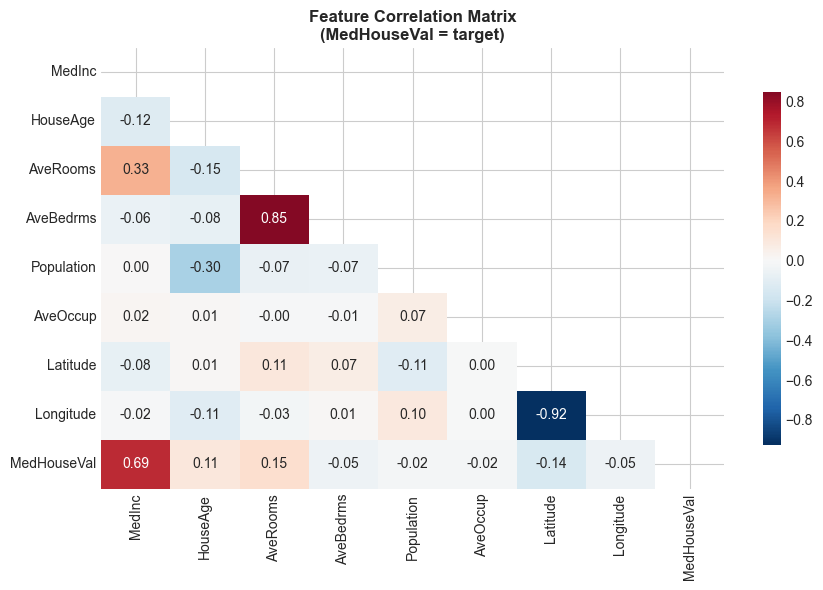


🔍 Top correlations with house value:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160


In [9]:
# ── Correlation Heatmap ──────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix\n(MedHouseVal = target)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Top correlations with house value:")
print(corr['MedHouseVal'].sort_values(ascending=False)[1:].to_string())

🏠 California Housing — Multiple Linear Regression Results
   R² without scaling: 0.5758
   R² with scaling:    0.5758
   (For sklearn's LR, scaling doesn't change R² — but matters for GD!)


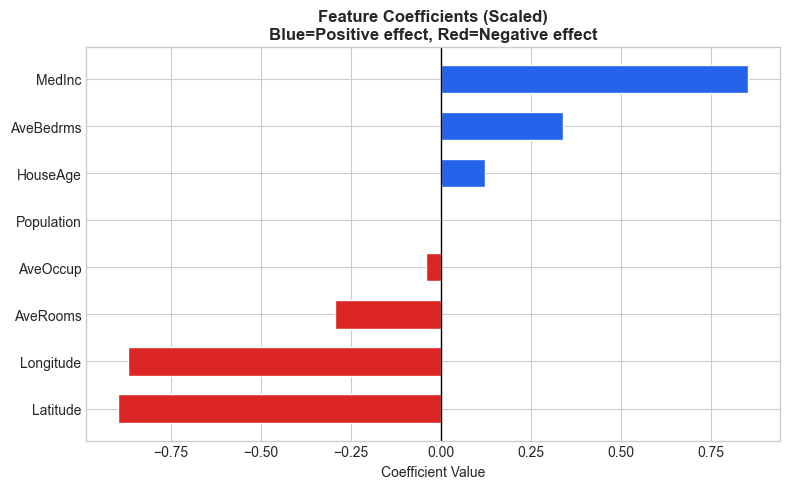

In [10]:
# ── Train Multiple LR Model ──────────────────────────────────────────────────

X_multi = df.drop('MedHouseVal', axis=1)
y_multi = df['MedHouseVal']

X_tr, X_te, y_tr, y_te = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Without scaling
lr_no_scale = LinearRegression().fit(X_tr, y_tr)
r2_no_scale = r2_score(y_te, lr_no_scale.predict(X_te))

# With scaling
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

lr_scaled = LinearRegression().fit(X_tr_sc, y_tr)
r2_scaled = r2_score(y_te, lr_scaled.predict(X_te_sc))

print("🏠 California Housing — Multiple Linear Regression Results")
print(f"   R² without scaling: {r2_no_scale:.4f}")
print(f"   R² with scaling:    {r2_scaled:.4f}")
print("   (For sklearn's LR, scaling doesn't change R² — but matters for GD!)")

# Coefficient plot
coef_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': lr_scaled.coef_
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = [COLORS['secondary'] if c < 0 else COLORS['primary'] for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=1)
ax.set_title('Feature Coefficients (Scaled)\nBlue=Positive effect, Red=Negative effect', 
             fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

---
## 8️ Assumptions of Linear Regression

Linear regression has **4 key assumptions** (remember: **LINE**):

| Letter | Assumption | How to check |
|--------|-----------|---------------|
| **L** | **L**inearity | Scatter plot of X vs y |
| **I** | **I**ndependence of errors | Durbin-Watson test |
| **N** | **N**ormality of residuals | Q-Q plot, histogram |
| **E** | **E**qual variance (homoscedasticity) | Residuals vs fitted plot |


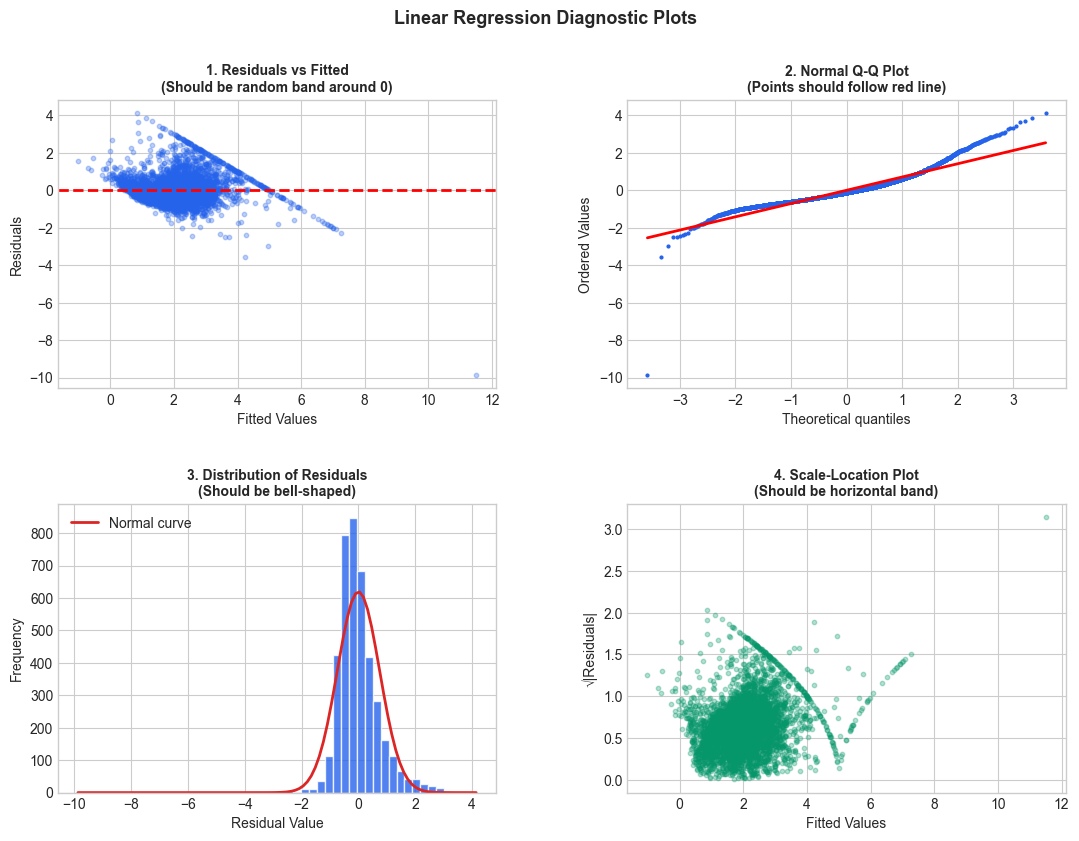

In [11]:
# ── DIAGNOSTIC PLOTS ────────────────────────────────────────────────────────
from scipy import stats

y_pred_all = lr_scaled.predict(X_te_sc)
residuals  = y_te.values - y_pred_all

fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1. Residuals vs Fitted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_pred_all, residuals, alpha=0.3, color=COLORS['primary'], s=10)
ax1.axhline(0, color='red', lw=2, linestyle='--')
ax1.set_xlabel('Fitted Values'); ax1.set_ylabel('Residuals')
ax1.set_title('1. Residuals vs Fitted\n(Should be random band around 0)', fontweight='bold', fontsize=10)

# 2. Q-Q Plot
ax2 = fig.add_subplot(gs[0, 1])
stats.probplot(residuals, dist='norm', plot=ax2)
ax2.set_title('2. Normal Q-Q Plot\n(Points should follow red line)', fontweight='bold', fontsize=10)
ax2.get_lines()[0].set(color=COLORS['primary'], markersize=2)
ax2.get_lines()[1].set(color='red', lw=2)

# 3. Histogram of residuals
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(residuals, bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.8)
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
ax3.plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()) * len(residuals) * (residuals.max()-residuals.min())/50,
         color=COLORS['secondary'], lw=2, label='Normal curve')
ax3.set_xlabel('Residual Value'); ax3.set_ylabel('Frequency')
ax3.set_title('3. Distribution of Residuals\n(Should be bell-shaped)', fontweight='bold', fontsize=10)
ax3.legend()

# 4. Scale-Location (sqrt(|residuals|) vs fitted)
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y_pred_all, np.sqrt(np.abs(residuals)), alpha=0.3, color=COLORS['accent'], s=10)
ax4.set_xlabel('Fitted Values'); ax4.set_ylabel('√|Residuals|')
ax4.set_title('4. Scale-Location Plot\n(Should be horizontal band)', fontweight='bold', fontsize=10)

plt.suptitle('Linear Regression Diagnostic Plots', fontsize=13, fontweight='bold')
plt.show()

---
## 9️ Regularization — Ridge & Lasso

**Problem:** When we have many features, models can **overfit** (memorize training data but fail on new data).

**Solution:** Add a **penalty term** to the cost function that discourages large coefficients.

| Method | Cost Function | Effect |
|--------|--------------|--------|
| **OLS** (plain) | $MSE$ | No penalty |
| **Ridge (L2)** | $MSE + \alpha \sum \theta_j^2$ | Shrinks coefficients toward 0 |
| **Lasso (L1)** | $MSE + \alpha \sum |\theta_j|$ | Can set coefficients exactly to 0 (feature selection!) |

The **$\alpha$ (alpha)** hyperparameter controls the strength of regularization:
- **$\alpha = 0$** → Same as plain linear regression
- **Large $\alpha$** → Strong shrinkage

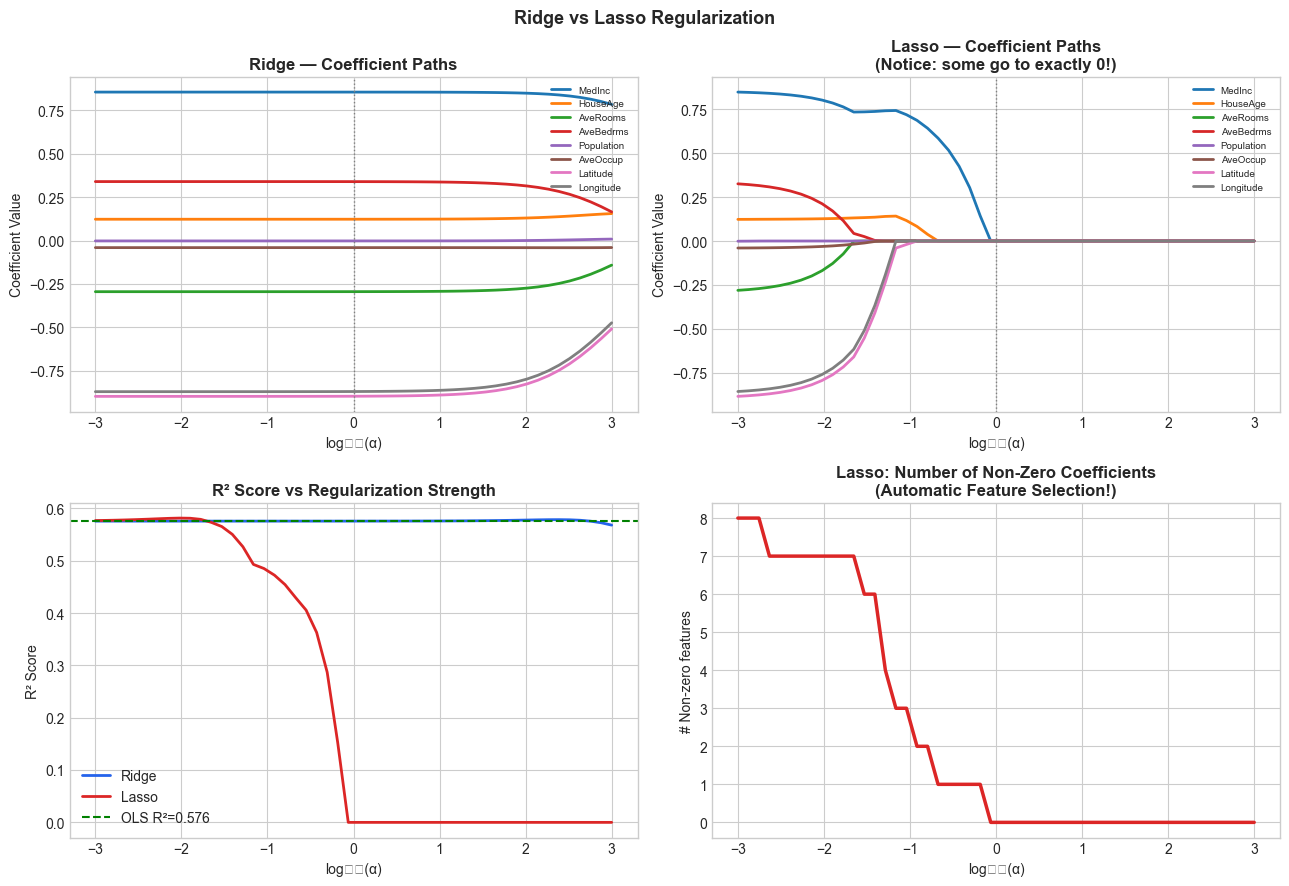

In [12]:
# ── RIDGE vs LASSO COMPARISON ────────────────────────────────────────────────

alphas = np.logspace(-3, 3, 50)   # range from 0.001 to 1000

ridge_coefs = []
lasso_coefs = []
ridge_r2    = []
lasso_r2    = []

for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a).fit(X_tr_sc, y_tr)
    ridge_coefs.append(ridge.coef_)
    ridge_r2.append(r2_score(y_te, ridge.predict(X_te_sc)))
    
    # Lasso
    lasso = Lasso(alpha=a, max_iter=5000).fit(X_tr_sc, y_tr)
    lasso_coefs.append(lasso.coef_)
    lasso_r2.append(r2_score(y_te, lasso.predict(X_te_sc)))

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
feature_names = list(X_multi.columns)
palette = plt.cm.tab10.colors

# Ridge coefficient paths
for i, fname in enumerate(feature_names):
    axes[0,0].plot(np.log10(alphas), ridge_coefs[:, i], lw=2, color=palette[i], label=fname)
axes[0,0].set_title('Ridge — Coefficient Paths', fontweight='bold')
axes[0,0].set_xlabel('log₁₀(α)'); axes[0,0].set_ylabel('Coefficient Value')
axes[0,0].legend(fontsize=7); axes[0,0].axvline(0, color='gray', lw=1, linestyle=':')

# Lasso coefficient paths
for i, fname in enumerate(feature_names):
    axes[0,1].plot(np.log10(alphas), lasso_coefs[:, i], lw=2, color=palette[i], label=fname)
axes[0,1].set_title('Lasso — Coefficient Paths\n(Notice: some go to exactly 0!)', fontweight='bold')
axes[0,1].set_xlabel('log₁₀(α)'); axes[0,1].set_ylabel('Coefficient Value')
axes[0,1].legend(fontsize=7); axes[0,1].axvline(0, color='gray', lw=1, linestyle=':')

# R² comparison
axes[1,0].plot(np.log10(alphas), ridge_r2, color=COLORS['primary'], lw=2, label='Ridge')
axes[1,0].plot(np.log10(alphas), lasso_r2, color=COLORS['secondary'], lw=2, label='Lasso')
axes[1,0].axhline(r2_scaled, color='green', lw=1.5, linestyle='--', label=f'OLS R²={r2_scaled:.3f}')
axes[1,0].set_title('R² Score vs Regularization Strength', fontweight='bold')
axes[1,0].set_xlabel('log₁₀(α)'); axes[1,0].set_ylabel('R² Score')
axes[1,0].legend()

# Non-zero coefficients (Lasso feature selection)
n_nonzero = [np.sum(coef != 0) for coef in lasso_coefs]
axes[1,1].plot(np.log10(alphas), n_nonzero, color=COLORS['secondary'], lw=2.5)
axes[1,1].set_title('Lasso: Number of Non-Zero Coefficients\n(Automatic Feature Selection!)', fontweight='bold')
axes[1,1].set_xlabel('log₁₀(α)'); axes[1,1].set_ylabel('# Non-zero features')
axes[1,1].set_yticks(range(9))

plt.suptitle('Ridge vs Lasso Regularization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Lab Summary

### Key Concepts Learned Today

| Concept | Formula / Key Point |
|---------|--------------------|
| **Linear model** | $\hat{y} = \theta_0 + \theta_1 x_1 + \ldots + \theta_n x_n$ |
| **Cost function** | $J = \frac{1}{2m}\sum(\hat{y}-y)^2$ — minimize this |
| **Gradient Descent** | $\theta := \theta - \alpha \nabla J$ — iterative optimizer |
| **Normal Equation** | $\theta = (X^TX)^{-1}X^Ty$ — closed-form solution |
| **R² score** | How much variance is explained (0–1, higher=better) |
| **Assumptions** | LINE: Linearity, Independence, Normality, Equal variance |
| **Ridge (L2)** | Shrinks coefficients, never zero |
| **Lasso (L1)** | Shrinks + zeroes coefficients = automatic feature selection |

### When to Use Linear Regression
Continuous output (regression, not classification)  
 Roughly linear relationship between features and target  
 Need interpretability (what each feature contributes)  
 Good baseline before trying complex models  

### When NOT to Use It
Highly non-linear relationships → try polynomial features or tree-based models  
Categorical output → use Logistic Regression or other classifiers  
Many correlated features → use Ridge or dimensionality reduction first  

---
###  Further Reading
- [Scikit-learn Linear Regression](https://scikit-learn.org/stable/modules/linear_model.html)
- *Hands-On Machine Learning* by Aurélien Géron — Chapter 4
- [StatQuest: Linear Regression (YouTube)](https://www.youtube.com/watch?v=nk2CQITm_eo)

---
